# 02 · The behavioral edge - real, but unmeasurable at small n

Notebook 01 showed the mechanism: under 4/3/2/0 a drawn prediction forfeits the 3-point
goal-difference tier, so a draw on anything but a very even, low-scoring match is
*rules-based* −EV. Here we measure how much the field leaks that way - and stay honest
about what a single tournament can prove.

All player labels are pseudonyms (`p01`-`p11`; `self` = the engine's own player).

In [1]:
%matplotlib inline
import logging, pandas as pd, matplotlib.pyplot as plt
logging.getLogger("src.odds.reconstruct").setLevel(logging.ERROR)
from analysis.behavioral_edge import (build_match_evals, expected_leak,
                                       paired_vs_self, PICKS, _blend_weight, SELF)
picks = pd.read_csv(PICKS)
evals = build_match_evals(blend_weight=_blend_weight())
print(f"{len(picks)} picks · {picks['player'].nunique()} players · "
      f"{len(evals)} matches with a banked market snapshot")

799 picks · 12 players · 102 matches with a banked market snapshot


## 1. Expected EV-leak per player (no outcomes needed)

For each pick we know the EV-max pick from the market matrix. The **leak** is
`E[points(EV-max)] − E[points(their pick)] ≥ 0`. Summed per player it's the *size of the
prize* - computable before a ball is kicked, so it carries no outcome luck.

In [2]:
leaks = expected_leak(picks, evals)
rows = [{"player": L.player, "n": L.n, "leak_total": L.leak_total,
         "leak/match": L.leak_per_match, "from_draws": L.leak_from_draws,
         "n_draws": L.n_draws} for L in leaks.values()]
tbl = (pd.DataFrame(rows).sort_values("leak/match", ascending=False)
       .reset_index(drop=True))
tbl.round(2)

,player,n,leak_total,leak/match,from_draws,n_draws
0,p04,59,41.65,0.71,14.68,12
1,p10,72,42.31,0.59,25.21,21
2,p11,67,35.62,0.53,18.82,16
3,p09,53,22.96,0.43,11.05,11
4,p07,71,22.68,0.32,16.46,18
5,p03,62,14.48,0.23,4.15,5
6,p02,72,16.45,0.23,11.41,14
7,p01,67,14.41,0.22,8.01,10
8,p06,72,9.53,0.13,0.28,1
9,p08,60,7.04,0.12,4.60,8


Note where **`self`** lands: at the bottom, with a near-zero leak - by construction the
engine plays the EV-max pick, so it leaves almost nothing on the table.

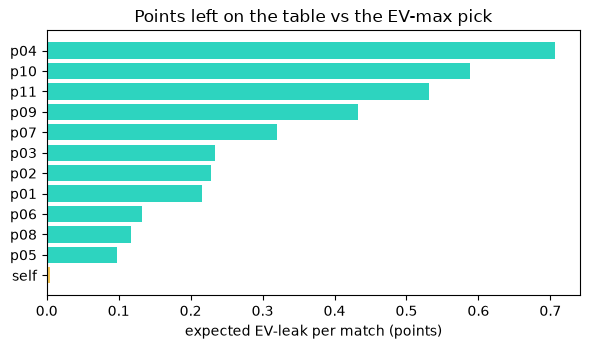

In [3]:
t = tbl.sort_values("leak/match")
plt.figure(figsize=(6,3.6))
colors = ["#f5c451" if p==SELF else "#2dd4bf" for p in t["player"]]
plt.barh(t["player"], t["leak/match"], color=colors)
plt.xlabel("expected EV-leak per match (points)")
plt.title("Points left on the table vs the EV-max pick")
plt.tight_layout(); plt.show()

## 2. Where the leak comes from - draws

Split each player's leak into the part flowing through **draw** picks vs everything else.

In [4]:
tbl2 = tbl.copy()
tbl2["draw_share_%"] = (tbl2["from_draws"] /
                        tbl2["leak_total"].where(tbl2["leak_total"] > 0)).fillna(0) * 100
tbl2[["player","leak_total","from_draws","draw_share_%","n_draws"]].round(1)

,player,leak_total,from_draws,draw_share_%,n_draws
0,p04,41.6,14.7,35.3,12
1,p10,42.3,25.2,59.6,21
2,p11,35.6,18.8,52.8,16
3,p09,23.0,11.1,48.1,11
4,p07,22.7,16.5,72.6,18
5,p03,14.5,4.2,28.7,5
6,p02,16.4,11.4,69.4,14
7,p01,14.4,8.0,55.6,10
8,p06,9.5,0.3,2.9,1
9,p08,7.0,4.6,65.4,8


## 3. The realized test - paired differentials

The expected leak is outcome-free. Do the points actually show up? Pair the engine
(`self`) against each opponent on the matches **both** played, and compute the mean
per-match point differential, its information coefficient, and t-stats - now, and
projected to a full 104-match tournament.

In [5]:
paired = paired_vs_self(picks, evals)
pr = pd.DataFrame([{"opponent": r.opponent, "n": r.n, "mu_diff": r.mu_d,
                    "IC": r.ic, "t_now": float(r.t_now),
                    "t_proj@104": float(r.t_proj_104)} for r in paired])
pr.sort_values("t_now", ascending=False).round(3).reset_index(drop=True)

,opponent,n,mu_diff,IC,t_now,t_proj@104
0,p04,59,0.915,0.657,5.046,6.700
1,p11,67,0.597,0.404,3.307,4.120
2,p08,60,0.350,0.332,2.570,3.384
3,p09,53,0.547,0.332,2.418,3.387
4,p07,71,0.310,0.201,1.689,2.045
5,p10,72,0.264,0.145,1.233,1.482
6,p03,62,0.177,0.150,1.183,1.532
7,p06,72,0.097,0.107,0.910,1.094
8,p05,72,0.111,0.105,0.893,1.073
9,p01,67,0.075,0.053,0.431,0.537


### The honest conclusion

Two things are true at once:

- **The mechanism is real and measurable now.** Every opponent shows a positive
  expected EV-leak, most of it flowing through draw picks; the engine's own leak sits
  near zero. This needs *no outcomes* - it is a property of the scoring rules and the
  shared market matrix.
- **The edge is not statistically detectable over one tournament.** The *predictive*
  edge (forecasting scores better than the market) is ≈ 0 - everyone reads the same
  odds. The realized behavioral differentials point the right way but are small; the
  `t_now` values are borderline and `t_proj@104` shows how far even a full season is
  from significance.

> **Mechanisms can be real while the edge is statistically unmeasurable at small n.**
> The value here is the discipline: quantify the mechanism precisely, and refuse to
> dress up a borderline t-stat as a proven edge.